# Figure S13

Illustrates the groundwater drought-response metrics used for classification.


In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch
from scipy.interpolate import PchipInterpolator


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'outputs' / 'RECON_MAIN_2011_2023').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')


ROOT = find_repo_root()
OUT_DIR = ROOT / 'outputs' / 'figures' / 'FigS13'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_PATH = OUT_DIR / 'FigS13.png'

DECLINE = '#C56B3F'
EARLY = '#2B8C8C'
HALF = '#76558A'
LONG = '#3D7F55'
CURVE = '#304C63'
REFERENCE = '#6F7478'

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 8.5,
    'axes.labelsize': 9.5,
    'xtick.labelsize': 8.0,
    'ytick.labelsize': 8.0,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.65,
    'ytick.major.width': 0.65,
    'xtick.major.size': 3.0,
    'ytick.major.size': 3.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})


In [2]:
def double_arrow(ax, start, end, color, lw=1.35, mutation_scale=8, zorder=6):
    arrow = FancyArrowPatch(
        start, end, arrowstyle='<->', mutation_scale=mutation_scale,
        color=color, linewidth=lw, shrinkA=0, shrinkB=0, zorder=zorder,
    )
    ax.add_patch(arrow)
    return arrow


event_months = pd.date_range('2012-01-01', '2013-04-01', freq='MS')
event_wtd = np.array([4.5, 4.2, 4.0, 4.1, 4.5, 5.2, 6.2, 7.3, 8.0, 7.7, 7.2, 6.6, 6.0, 5.4, 5.0, 5.1])
event_x = mdates.date2num(event_months)
event_dense_x = np.linspace(event_x.min(), event_x.max(), 500)
event_dense_wtd = PchipInterpolator(event_x, event_wtd)(event_dense_x)

t_pre, w_pre = event_x[2], event_wtd[2]
t_peak, w_peak = event_x[8], event_wtd[8]
t_early, w_early = event_x[14], event_wtd[14]
maximum_decline = w_peak - w_pre
w_half = w_peak - 0.5 * maximum_decline
t_half = event_x[12]

long_years = np.array([
    2011.00, 2011.25, 2011.50, 2011.75, 2012.00, 2012.25, 2012.50, 2012.75,
    2013.00, 2014.00, 2015.00, 2016.00, 2017.00, 2018.00,
    2019.00, 2019.25, 2019.50, 2019.75, 2020.00,
])
long_wtd = np.array([
    4.5, 4.2, 4.7, 4.6, 4.4, 4.8, 6.4, 8.2,
    7.5, 6.7, 6.3, 5.9, 5.7, 5.5, 5.3, 5.0, 5.2, 5.4, 5.1,
])
long_dense_x = np.linspace(long_years.min(), long_years.max(), 900)
long_dense_wtd = PchipInterpolator(long_years, long_wtd)(long_dense_x)
baseline_2011 = 4.5
peak_2012 = 8.2
mean_2019 = 5.2


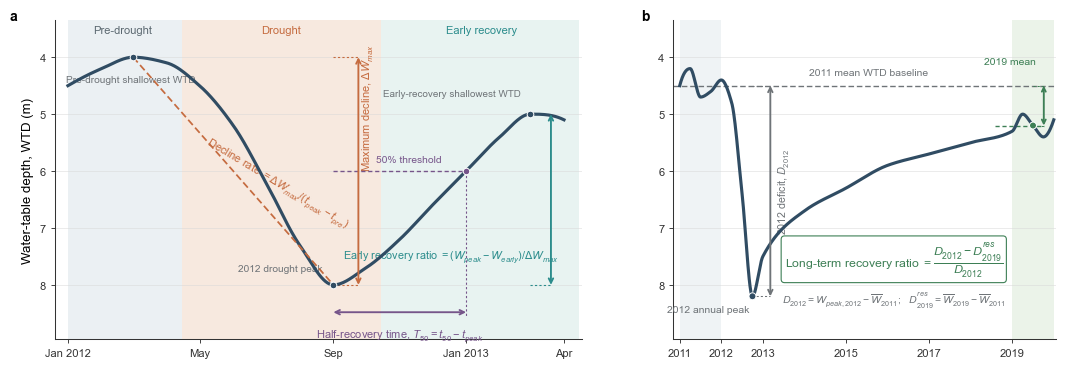

Saved: outputs\figures\FigS13\FigS13.png


In [3]:
fig, (ax, ax_long) = plt.subplots(1, 2, figsize=(11.0, 4.25), gridspec_kw={'width_ratios': [1.38, 1.0]})
fig.subplots_adjust(left=0.075, right=0.985, bottom=0.18, top=0.93, wspace=0.20)

ax.axvspan(pd.Timestamp('2012-01-01'), pd.Timestamp('2012-04-15'), color='#DCE5EA', alpha=0.55, lw=0)
ax.axvspan(pd.Timestamp('2012-04-15'), pd.Timestamp('2012-10-15'), color='#F1D8C6', alpha=0.55, lw=0)
ax.axvspan(pd.Timestamp('2012-10-15'), pd.Timestamp('2013-04-15'), color='#D8ECE8', alpha=0.58, lw=0)
ax.plot(mdates.num2date(event_dense_x), event_dense_wtd, color=CURVE, lw=2.25, zorder=4)
ax.scatter(mdates.num2date([t_pre, t_peak, t_early]), [w_pre, w_peak, w_early], s=23, color=CURVE, edgecolor='white', linewidth=0.7, zorder=7)

ax.text(pd.Timestamp('2012-02-20'), 3.53, 'Pre-drought', color='#5B6870', ha='center', va='center', fontsize=8.0)
ax.text(pd.Timestamp('2012-07-15'), 3.53, 'Drought', color=DECLINE, ha='center', va='center', fontsize=8.0)
ax.text(pd.Timestamp('2013-01-15'), 3.53, 'Early recovery', color=EARLY, ha='center', va='center', fontsize=8.0)

decline_x = mdates.date2num(pd.Timestamp('2012-09-24'))
ax.hlines([w_pre, w_peak], t_peak, decline_x, color=DECLINE, lw=0.8, linestyles=(0, (2, 2)), zorder=3)
double_arrow(ax, (decline_x, w_pre), (decline_x, w_peak), DECLINE)
ax.text(mdates.num2date(decline_x + 9), 0.5 * (w_pre + w_peak),
        r'Maximum decline, $\Delta W_{max}$', color=DECLINE, rotation=90,
        ha='center', va='bottom', fontsize=8.0)
ax.plot(mdates.num2date([t_pre, t_peak]), [w_pre, w_peak], color=DECLINE, lw=1.25, ls=(0, (4, 2)), zorder=5)
ax.text(pd.Timestamp('2012-05-04'), 5.60,
        r'Decline rate $=\Delta W_{max}/(t_{peak}-t_{pre})$',
        color=DECLINE, rotation=-31, rotation_mode='anchor', ha='left', va='bottom', fontsize=8.0)

early_x = mdates.date2num(pd.Timestamp('2013-03-20'))
ax.hlines([w_peak, w_early], t_early, early_x, color=EARLY, lw=0.8, linestyles=(0, (2, 2)), zorder=3)
double_arrow(ax, (early_x, w_peak), (early_x, w_early), EARLY)
ax.text(pd.Timestamp('2012-12-18'), 7.48,
        r'Early recovery ratio $=(W_{peak}-W_{early})/\Delta W_{max}$',
        color=EARLY, ha='center', va='center', fontsize=7.8)

ax.hlines(w_half, t_peak, t_half, color=HALF, lw=1.0, linestyles=(0, (3, 2)), zorder=3)
ax.vlines(t_half, w_half, 8.55, color=HALF, lw=0.8, linestyles=(0, (2, 2)), zorder=3)
ax.scatter(mdates.num2date([t_half]), [w_half], s=22, color=HALF, edgecolor='white', linewidth=0.7, zorder=7)
double_arrow(ax, (t_peak, 8.48), (t_half, 8.48), HALF)
ax.text(mdates.num2date(0.5 * (t_peak + t_half)), 8.72,
        r'Half-recovery time, $T_{50}=t_{50}-t_{peak}$',
        color=HALF, ha='center', va='top', fontsize=8.0)
ax.text(pd.Timestamp('2012-10-10'), w_half - 0.12, '50% threshold', color=HALF, ha='left', va='bottom', fontsize=7.4)

ax.annotate('Pre-drought shallowest WTD', (mdates.num2date(t_pre), w_pre), xytext=(-2, -18),
            textcoords='offset points', ha='center', color=REFERENCE, fontsize=7.3)
ax.annotate('2012 drought peak', (mdates.num2date(t_peak), w_peak), xytext=(-8, 10),
            textcoords='offset points', ha='right', color=REFERENCE, fontsize=7.3)
ax.annotate('Early-recovery shallowest WTD', (mdates.num2date(t_early), w_early), xytext=(-7, 13),
            textcoords='offset points', ha='right', color=REFERENCE, fontsize=7.1)

ax.set_xlim(pd.Timestamp('2011-12-20'), pd.Timestamp('2013-04-18'))
ax.set_ylim(8.95, 3.35)
ax.set_ylabel('Water-table depth, WTD (m)')
ax.set_xticks(pd.to_datetime(['2012-01-01', '2012-05-01', '2012-09-01', '2013-01-01', '2013-04-01']))
ax.set_xticklabels(['Jan 2012', 'May', 'Sep', 'Jan 2013', 'Apr'])
ax.set_yticks([4, 5, 6, 7, 8])
ax.grid(axis='y', color='#D9D9D9', lw=0.55, alpha=0.65, zorder=0)
ax.text(-0.085, 1.035, 'a', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top')

ax_long.plot(long_dense_x, long_dense_wtd, color=CURVE, lw=2.25, zorder=4)
ax_long.axvspan(2011, 2012, color='#DCE5EA', alpha=0.45, lw=0)
ax_long.axvspan(2019, 2020, color='#DDEBDA', alpha=0.58, lw=0)
ax_long.axhline(baseline_2011, color=REFERENCE, lw=1.0, ls=(0, (4, 2)), zorder=2)
ax_long.axhline(mean_2019, xmin=0.84, xmax=0.97, color=LONG, lw=1.0, ls=(0, (3, 2)), zorder=2)
ax_long.scatter([2012.75, 2019.50], [peak_2012, mean_2019], s=25, color=[CURVE, LONG], edgecolor='white', linewidth=0.7, zorder=7)

deficit_x = 2013.18
ax_long.hlines([baseline_2011, peak_2012], 2012.75, deficit_x, color=REFERENCE, lw=0.75, linestyles=(0, (2, 2)))
double_arrow(ax_long, (deficit_x, baseline_2011), (deficit_x, peak_2012), REFERENCE)
ax_long.text(deficit_x + 0.13, 6.35, r'2012 deficit, $D_{2012}$', color=REFERENCE, rotation=90, ha='left', va='center', fontsize=7.7)

residual_x = 2019.76
ax_long.hlines([baseline_2011, mean_2019], 2019.50, residual_x, color=LONG, lw=0.75, linestyles=(0, (2, 2)))
double_arrow(ax_long, (residual_x, baseline_2011), (residual_x, mean_2019), LONG, mutation_scale=7)
ax_long.text(2019.58, 4.15, '2019 mean', color=LONG, ha='right', va='bottom', fontsize=7.5)
ax_long.text(2014.10, baseline_2011 - 0.16, '2011 mean WTD baseline', color=REFERENCE, ha='left', va='bottom', fontsize=7.5)
ax_long.text(2012.67, peak_2012 + 0.15, '2012 annual peak', color=REFERENCE, ha='right', va='top', fontsize=7.5)
ax_long.text(2016.15, 7.55,
             r'Long-term recovery ratio $=\dfrac{D_{2012}-D_{2019}^{res}}{D_{2012}}$',
             color=LONG, ha='center', va='center', fontsize=8.8,
             bbox=dict(boxstyle='round,pad=0.28', facecolor='white', edgecolor=LONG, linewidth=0.8))
ax_long.text(2016.15, 8.25,
             r'$D_{2012}=W_{peak,2012}-\overline{W}_{2011}$;   $D_{2019}^{res}=\overline{W}_{2019}-\overline{W}_{2011}$',
             color=REFERENCE, ha='center', va='center', fontsize=7.5)

ax_long.set_xlim(2010.85, 2020.05)
ax_long.set_ylim(8.95, 3.35)
ax_long.set_xticks([2011, 2012, 2013, 2015, 2017, 2019])
ax_long.set_xticklabels(['2011', '2012', '2013', '2015', '2017', '2019'])
ax_long.set_yticks([4, 5, 6, 7, 8])
ax_long.grid(axis='y', color='#D9D9D9', lw=0.55, alpha=0.65, zorder=0)
ax_long.text(-0.085, 1.035, 'b', transform=ax_long.transAxes, fontsize=10, fontweight='bold', va='top')

for current_ax in (ax, ax_long):
    current_ax.spines['left'].set_color('#333333')
    current_ax.spines['bottom'].set_color('#333333')
    current_ax.tick_params(colors='#333333')

fig.savefig(FIG_PATH, dpi=600, facecolor='white')
plt.show()
print('Saved:', FIG_PATH.relative_to(ROOT))
